# Análise Exploratória da Copa do Mundo

### Nesse projeto usaremos dados das copas do mundo, desde 1930 até 2014, para analisar duas afirmações que comumente são feitas à cerca deste campeonato.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

In [2]:
from deep_translator import GoogleTranslator
tradutor = GoogleTranslator(source='en', target='pt')

In [3]:
partidas = pd.read_csv('WorldCupMatches.csv')
copas = pd.read_csv('WorldCups.csv')

## 1) Uma afirmação muito comum a respeito da copa do mundo é a de que os países sede têm uma certa vantagem por jogarem em casa diante de sua torcida. Para analisar o impacto de jogar o torneio em casa, vamos comparar o desempenho dos países sede de cada edição com o desempenho médio deste país em outras edições. As métricas utilizadas serão: porcentagem de vitória, média de gols e resultado final.

In [4]:
# Como a copa de 2002 teve dois países sede, temos que colocar os países em linhas diferentes
copia_da_linha = copas[copas['Year'] == 2002]
copia_da_linha['Country'] = 'Japan'
copas.loc[16, 'Country'] = 'Korea Republic'
copas = pd.concat([copas.loc[:16], copia_da_linha, copas.loc[16:]]).reset_index(drop=True)

In [5]:
# Obtendo o país sede de cada copa
sede = copas[['Year', 'Country']]

In [6]:
# Incluindo o país sede na tabela de partidas
partidas = partidas.merge(sede, on='Year')

In [7]:
# Selecionando os jogos em que o país sede participa
# Essa base de dados não necessariamente coloca o país sede na coluna de "Host Team", então também precisamos procurar na coluna dos times visitantes 
jogos_do_anfitriao = partidas[(partidas['Away Team Name'] == partidas['Country']) | (partidas['Home Team Name'] == partidas['Country'])]

In [8]:
# Indentificando quantos gols o país sede fez em uma partida
jogos_do_anfitriao['Host Goals'] = jogos_do_anfitriao.apply(
    lambda row: row['Home Team Goals'] if row['Home Team Name'] == row['Country'] else row['Away Team Goals'], axis=1
)
# Indentificando quantos gols o país sede sofreu em uma partida
jogos_do_anfitriao['Opponent Goals'] = jogos_do_anfitriao.apply(
    lambda row: row['Home Team Goals'] if not row['Country'] else row['Away Team Goals'], axis=1
)

In [9]:
# Checando se o país sede ganhou uma partida
jogos_do_anfitriao['Host Wins'] = jogos_do_anfitriao['Host Goals'] > jogos_do_anfitriao['Opponent Goals']

### O gráfico abiaxo demonstra que os times da casa levam uma pequena vantagem na copa do mundo, ganhando a maioria dos jogos, mas para avaliarmos o quão relevante é essa vantagem, precisamos aprofundar a análise.

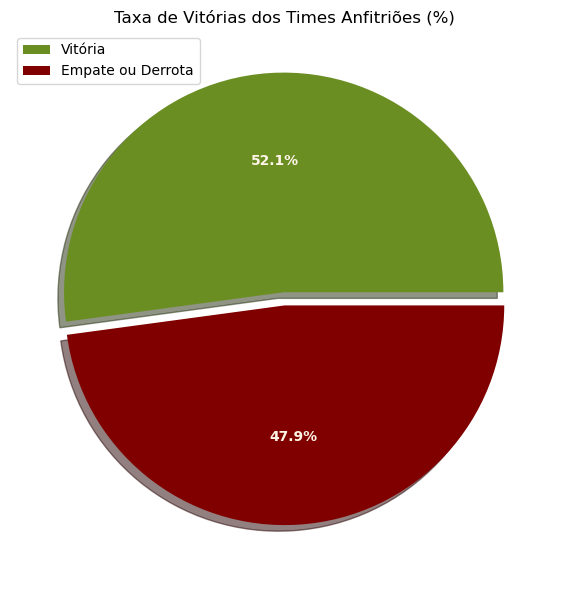

In [10]:
# Plotando a taxa de vitória dos países sede
resultados = jogos_do_anfitriao['Host Wins'].value_counts().reset_index().replace({True: 'Vitória', False: 'Empate ou Derrota'})
plt.figure(figsize=(6, 6))
explode_setting = [0.06, 0]

plt.pie(
    resultados['count'],
    colors=['olivedrab', 'maroon'],
    explode=explode_setting,
    autopct='%1.1f%%',
    shadow=True,
    labeldistance=0.3, 
    textprops={'color': "oldlace", 'weight': 'bold'}
)
plt.title("Taxa de Vitórias dos Times Anfitriões (%)")
plt.legend(resultados['Host Wins'], loc='upper left')
plt.tight_layout()
plt.show()

In [11]:
# Calculando a média de gols dos países que sediaram a copa
media_de_gols_anfitriao = jogos_do_anfitriao.groupby('Country').agg({'Host Goals': 'mean'}).rename(columns={'Host Goals': 'Media como Anfitriao'})

In [12]:
# Calculando a média de gols desses mesmos países quando disputaram a copa em outro país 
paises = sede['Country']
media_de_gols = dict()

for pais in paises:
    pais_como_visitante = partidas[((partidas['Home Team Name'] == pais) | (partidas['Away Team Name'] == pais)) & (partidas['Country'] != pais)]
    pais_como_visitante['Goals Pro'] = pais_como_visitante.apply(
        lambda row: row['Home Team Goals'] if row['Home Team Name'] == pais else row['Away Team Goals'], axis=1
    )
    media_de_gols[pais] = pais_como_visitante['Goals Pro'].mean()
media_de_gols_visitante = pd.DataFrame(index=media_de_gols.keys(), data=media_de_gols.values(), columns=['Media como Visitante'])

In [13]:
# Comparando a média de gols dentro e fora de casa
media_de_gols = media_de_gols_anfitriao.merge(media_de_gols_visitante, on=media_de_gols_anfitriao.index).rename(columns={'key_0': 'Pais'}).set_index('Pais')

In [14]:
# Traduzindo o nome dos países sede para português
nomes_em_portugues = {pais: tradutor.translate(pais) for pais in media_de_gols.index.to_list()}

### Esse gráfico demonstra que, em geral, os países fizeram mais gols quando sediam a copa, dos 16 países sede, 12 tiveram uma média de gols maior jogando em casa.

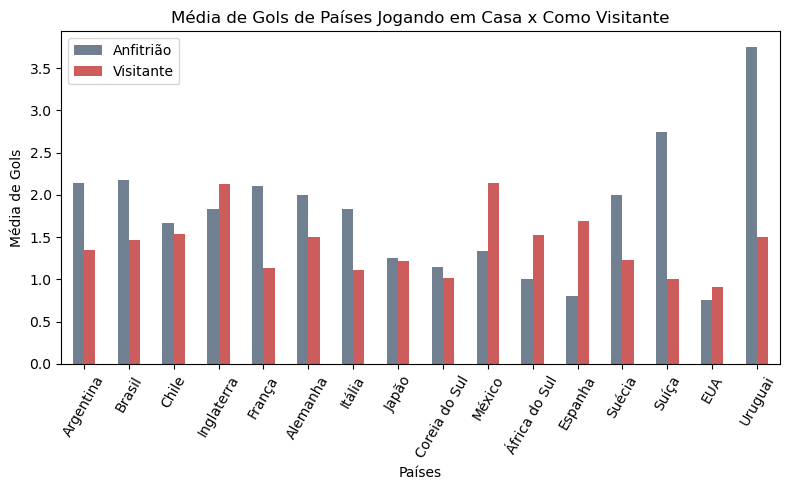

In [15]:
# Plotando a comparação entre médias de gols
media_de_gols.index = nomes_em_portugues.values()
ax = media_de_gols.plot(kind='bar', figsize=(8, 5), width=0.5, color=['slategrey', 'indianred'])
plt.title('Média de Gols de Países Jogando em Casa x Como Visitante')
plt.xlabel('Países')
plt.ylabel('Média de Gols')
plt.xticks(rotation=60)  
ax.legend(['Anfitrião', 'Visitante'])
plt.tight_layout()
plt.show()

### O gráfico a seguir apresenta outra forma de visualizar o desempenho dos países jogando em casa, os países que aparecem acima da linha vermelha marcaram mais gols em casa do que quando jogaram como visitantes. Aqui destacam-se o Uruguai e a Suíça por terem um desempenho muito superior jogando em casa, enquanto México e Inglaterra tiveram uma performance abaixo do  habitual quando sediaram a copa.

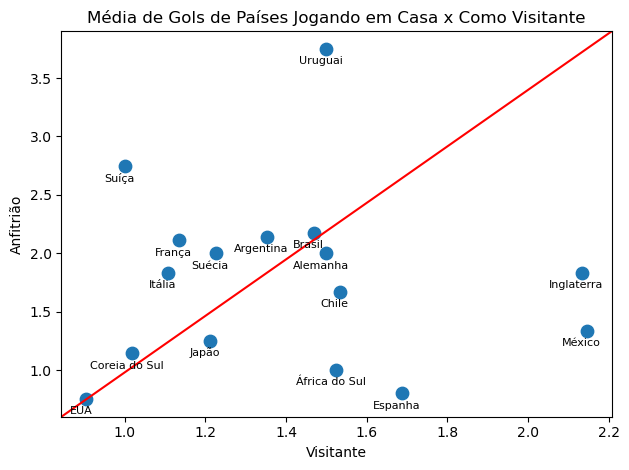

In [16]:
# Plotando a comparação entre médias de gols em gráfico de dispersão
fig, ax = plt.subplots()
media_de_gols.index = nomes_em_portugues.values()
ax.scatter(y=media_de_gols['Media como Anfitriao'], x=media_de_gols['Media como Visitante'],  s=80)
plt.title('Média de Gols de Países Jogando em Casa x Como Visitante')
plt.ylabel('Anfitrião')
plt.xlabel('Visitante')
for i, label in enumerate(media_de_gols.index.to_list()):
    ax.annotate(
        label,                     
        (media_de_gols['Media como Visitante'].iloc[i], media_de_gols['Media como Anfitriao'].iloc[i]),               
        textcoords="offset points",
        xytext=(-4, -11),   
        ha='center', 
        fontsize=8
    )
line = mlines.Line2D([0, 1], [0, 1], color='red')
transform = ax.transAxes
line.set_transform(transform)
ax.add_line(line)
plt.tight_layout()

plt.show()

In [17]:
# A base de dados apresenta variação das nomenclaturas de fase em copas diferentes, então precisamos padronizar
padrao = {
          'Match for third place': 'Play-off for third place', 
          'Third place': 'Play-off for third place',
          'Group 6': 'Final'
         }
padrao.update({'Group ' + k : 'Group stage' for k in '1234ABCDEFGHIJ'})

In [18]:
# Obtendo o último jogo disputado pelo país sede
ultimo_jogo_do_anfitriao = jogos_do_anfitriao.groupby(['Country', 'Year']).agg({'RoundID': 'max'})
# Indentificando o quão longe o país sede foi na copa
fase_atingida_anfitriao = jogos_do_anfitriao[jogos_do_anfitriao['RoundID'].isin(
    ultimo_jogo_do_anfitriao['RoundID'].values.tolist())][['Year', 'Country', 'Stage']]
# Padronizando o nome das fases
fase_atingida_anfitriao = fase_atingida_anfitriao.drop_duplicates().replace(padrao)
# A copa de 2002 teve uma entrada duplicada devido ao número de países sede
fase_atingida_anfitriao = fase_atingida_anfitriao.drop(745)
# Removendo coluna desnecessária e reindexando
fase_atingida_anfitriao = fase_atingida_anfitriao.drop(columns='Year')
fase_atingida_anfitriao = fase_atingida_anfitriao.set_index('Country')

In [19]:
# Indentificando o quão longe os países chegaram jogando fora de casa
fase_atingida_como_visitante = pd.DataFrame()
for ano in pais_como_visitante['Year']:
    posicoes = pd.DataFrame()
    for pais in paises:
        posicao = pais_como_visitante[(pais_como_visitante['Year'] == ano) & (
            (pais_como_visitante['Home Team Name'] == pais) | (pais_como_visitante['Away Team Name'] == pais))]
        if not posicao['Stage'].empty:
            posicao = {'Country': pais, 'Stage': posicao['Stage'].iloc[-1], 'Year': ano}
            posicoes = pd.concat([posicoes, pd.DataFrame(posicao, index=[0])]).drop_duplicates()
    fase_atingida_como_visitante = pd.concat([fase_atingida_como_visitante , posicoes]).drop_duplicates()
# Padronizando o nome das fases
fase_atingida_como_visitante = fase_atingida_como_visitante.replace(padrao)  

In [20]:
# Desemenho mais comum dos países jogando como visitantes
fase_mais_comum_visitante = fase_atingida_como_visitante.groupby('Country').agg({'Stage': lambda x: x.mode().iat[0]})

In [21]:
# Desemenho mais comum dos países jogando em casa
fase_mais_comum_host = fase_atingida_anfitriao.groupby('Country').agg({'Stage': lambda x: x.mode().iat[0]})

In [22]:
# Quantificando o desempenho
escala = {'Not Qualified': 0, 'Preliminary round': 1, 'Group stage': 2, 'Round of 16': 3, 'Quarter-finals': 4, 'Semi-finals': 5, 'Play-off for third place': 6, 'Final': 7}

In [23]:
# Comparando o desempenho
diferenca_de_desempenho = pd.DataFrame.merge(fase_mais_comum_host, fase_mais_comum_visitante, on='Country', how='left')
diferenca_de_desempenho.rename(columns={'Stage_x': 'Host Stage', 'Stage_y': 'Away Stage'}, inplace=True)
diferenca_de_desempenho.fillna('Not Qualified', inplace=True)

,Host Stage,Away Stage
Country,,
Argentina,Final,Group stage
Brazil,Final,Final
Chile,Play-off for third place,Round of 16
England,Final,Group stage
France,Final,Quarter-finals
Germany,Play-off for third place,Final
Italy,Semi-finals,Final
Japan,Round of 16,Group stage
Korea Republic,Play-off for third place,Not Qualified


### Por fim, vamos analisar se países sede avançaram mais na competição em comparação com outras edições.

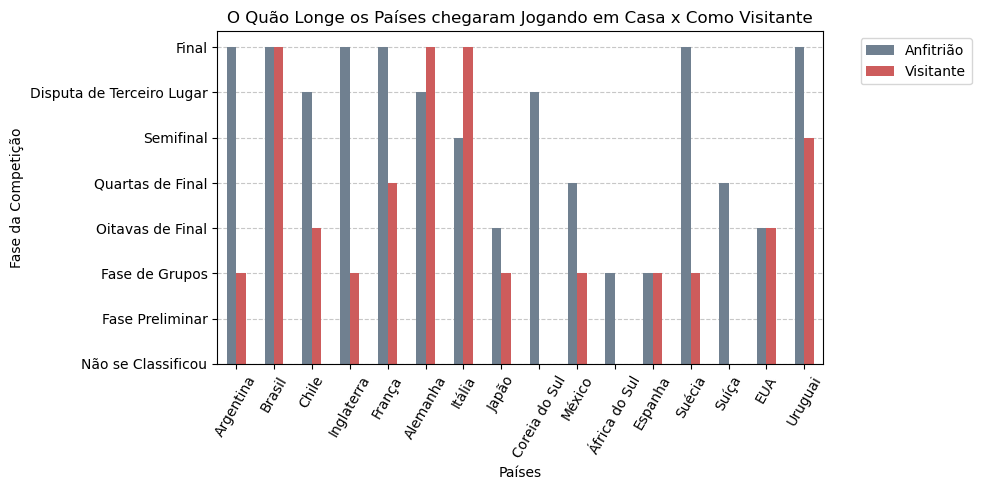

In [24]:
# Plotando a comparação de desempenho
plotar_diferenca = diferenca_de_desempenho.replace(escala)
plotar_diferenca.index = nomes_em_portugues.values()

ax = plotar_diferenca.plot(kind='bar', figsize=(10, 5), width=0.5, color=['slategrey', 'indianred'])

plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

# 3. Ensure grid lines stay behind the bars
plt.gca().set_axisbelow(True)

plt.title('O Quão Longe os Países chegaram Jogando em Casa x Como Visitante')
plt.xlabel('Países')
plt.ylabel('Fase da Competição')
plt.xticks(rotation=60)  
ax.legend(['Anfitrião', 'Visitante'], bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_yticks(range(len(escala)))
ax.set_yticklabels(['Não se Classificou', 'Fase Preliminar', 'Fase de Grupos', 'Oitavas de Final', 
                    'Quartas de Final', 'Semifinal', 'Disputa de Terceiro Lugar', 'Final'])

plt.tight_layout()
plt.show()

### No gráfico acima podemos perceber que em geral, os países chegam mais longe na competição quando sediam a copa, com exceção de Alemanha e Itália. Dois casos notáveis, são a Suécia, que em 1958 chegou a final como anfitriã e a Coréia do Sul que disputou o terceiro lugar em 2002, um desempenho muito superior se comparados aos resultados atingidos jogando fora de casa.

## Conclusão

### O "Fator Casa" parece ser relevante na copa do mundo, com os países sede fazendo mais gols e ganhando mais partidas. Porém não parece haver uma relação direta entre jogar em casa e ter um bom desempenho, essa vantagem parece ser mais relevantes quando o país sede não tem tradição em copas do mundo (caso de Suécia e Coréia do Sul), o fato desses times jogarem em casa foi uma mitivação a mais para que os países tivessem um bom desempenho. Enquanto, para países mais tradicionais no futebol, como Brasil, Alemanha e Itália que costumam ter boas atuações em todas copas, o fato de jogar em casa não parece ter sido um fator relevante no desempenho das equipes.

## 2) Outra afirmação bastante comum é a de que a copa foi se tornando mais competitiva ao longo do tempo. Conforme as estratégias de jogo formam sendo aprimoradas por comissões técnicas cada vez mais preparadas e multidisciplinares, o nível das equipes participantes foi subindo, fazendo com que vitórias com placares elásticos se tornassem cada vez mais raros.
### Para testar essa afirmação, iremos avaliar se existe uma diminuição considerável entre a média de gols de cada copa do mundo, em seguida, calcularemos a diferença média de gols nas partidas de cada copa.

### O gráfico abaixo mostra que o número total de gols marcados nas copas do mundo foi aumentando com o tempo, porém, temos que levar em consideração que as primeiras edições do torneio contavam com menos times participantes. Para ter um resultado significante, precisamos verificar a média de gols em cada copa. 

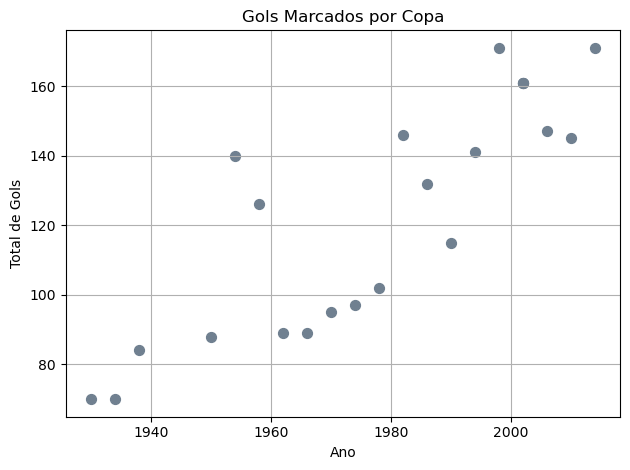

In [25]:
fig, ax = plt.subplots()
ax.scatter(y=copas['GoalsScored'], x=copas['Year'], color='slategrey',  s=50)
plt.title('Gols Marcados por Copa')
plt.ylabel('Total de Gols')
plt.xlabel('Ano')
ax.grid(True)
plt.tight_layout()
plt.show()

### No gráfico à seguir, notamos uma diminuição na média de gols com o passar do tempo. À partir dos anos 1980 a média de gols parece ter se estabilizado.

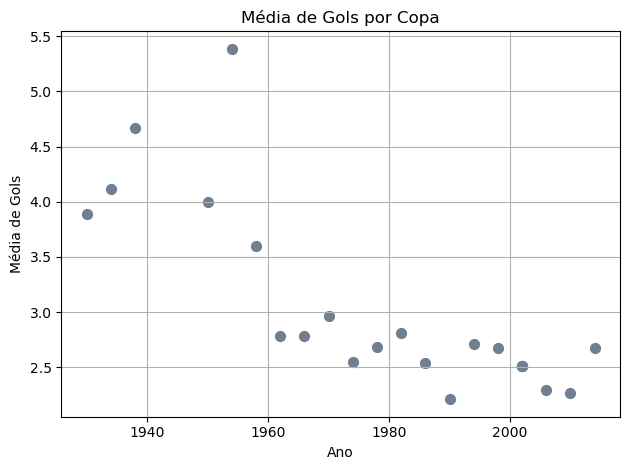

In [26]:
fig, ax = plt.subplots()
ax.scatter(y=copas['GoalsScored']/copas['MatchesPlayed'], x=copas['Year'], color='slategrey',  s=50)
plt.title('Média de Gols por Copa')
plt.ylabel('Média de Gols')
plt.xlabel('Ano')
ax.grid(True)
plt.tight_layout()
plt.show()

In [27]:
from scipy.stats import pearsonr

### Usando a correlação de Pearson, podemos perceber que a tendência de diminuição na média de gols de fato é significativa com um valor-p < 0.05

In [28]:
r, p = pearsonr(copas["Year"], copas["GoalsScored"]/copas['MatchesPlayed'])

print(f"Correlação de Pearson: {r:.3f}")
print(f"Valor-p: {p:.6f}")

Correlação de Pearson: -0.793
Valor-p: 0.000011


### Em relação ao saldo de gols dos times vencedores, notamos que as primeiras copas tinham mais ocorrência de placares elásticos, à partir dos anos 1960, houve uma redução na média dos daldos de gols.

In [29]:
partidas['GoalsDiff'] = abs(partidas['Home Team Goals'] - partidas['Away Team Goals'])

In [30]:
diferenca_media = partidas.groupby('Year').agg({'GoalsDiff': 'mean'})

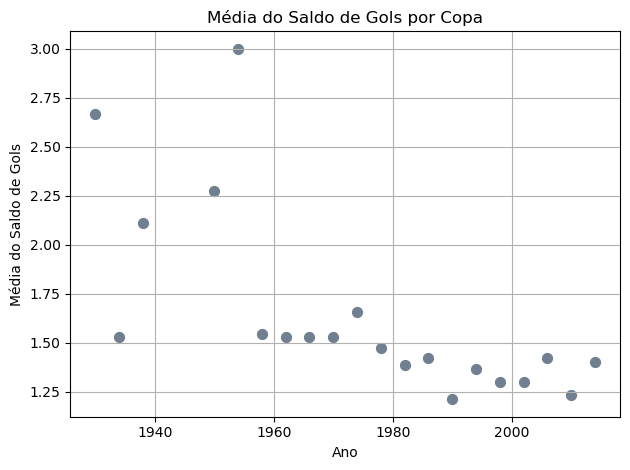

In [31]:
fig, ax = plt.subplots()
ax.scatter(x=diferenca_media.index, y=diferenca_media['GoalsDiff'], color='slategrey',  s=50)
plt.title('Média do Saldo de Gols por Copa')
plt.ylabel('Média do Saldo de Gols')
plt.xlabel('Ano')
ax.grid(True)
plt.tight_layout()
plt.show()

## Conclusão

### É notável a diminuição da média de gols com o passar do tempo, as primeiras copas tinham placares mais elásticos.